# Rebuttal figures: multi-seed replication, baselines, residual geometry

Renders figures R1–R8 from saved results. CPU only; nothing here loads a model.

| part | does |
|---|---|
| **1. Tables** | recomputes Tables E and F through `shared_truth.residuals` and checks them against the published CSVs |
| **2. Multi-seed** | R1 (α sweeps, 4 adapters per trajectory), R2 (τ₀ vs strict overshoot per run) |
| **3. Baselines** | R3 (accuracy vs α), R4 (AUROC vs α), R5 (Table E as bars) |
| **4. Residual geometry** | R6 (gap ratios), R7 (residual anisotropy), R8 (t_G read vs re-probe) |

**Populations.** All runs are pinned by `pair_id` (`residuals.run_ids`) and the notebook stops if one
is missing. The same 12 trained adapters (orig + seeds 42–44 on 3 trajectories) were swept twice:

- `__stmt_*`, **full test set** (n=2684): figures R1–R5, alongside the 6 baseline runs
  (random-weight, shuffled) that exist only on this eval. The original notebook globbed these.
- `__truth_*`, **simple statements** (n=1599): the eval behind the rebuttal's multi-seed claims and
  Table 7. Part 2 reports strict overshoot on both.

**Inputs.** Per-run `sweep_results.json`, the 3 activation dumps (~280 MB), and the analysis CSVs,
all from the results repo.

In [2]:
# --- setup ------------------------------------------------------------------
import os, sys, subprocess
from pathlib import Path

BRANCH   = "rebuttal"          # switch to "main" once merged
REPO_DIR = Path("/content/shared-truth")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "-q", "-b", BRANCH,
                    "https://github.com/KingTechnician/shared-truth.git", str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q"], check=True)
sys.path.insert(0, str(REPO_DIR))

try:
    from google.colab import userdata
    os.environ.setdefault("HF_TOKEN", userdata.get("HF_TOKEN"))
except Exception:
    pass

# Pin scikit-learn before anything imports it: Table F's re-probe is a
# LogisticRegression fit, and the published numbers came from 1.8.
from shared_truth import env
env.pin_sklearn()

import json, numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shared_truth import storage, metrics, naming, plots, residuals
print("shared_truth @", storage.provenance()["shared_truth_sha"])

scikit-learn 1.8.0 (matches probes)
shared_truth @ 5f64518eef5b070792c02f4077dfda7ba590fe75


In [3]:
# --- config -----------------------------------------------------------------
FIG_DIR     = Path("/content/figures_rebuttal")   # pdf + png per figure
TABLE_DIR   = Path("/content/rebuttal_tables")    # recomputed Tables E/F (unrounded + rounded)
REPROBE_TOL = residuals.REPROBE_TOL   # 0.01; Table F's re-probe only (see Part 1). All else exact.

In [4]:
# --- data root + pinned population -----------------------------------------
ROOT = Path(storage.fetch_results(include_dumps=True, include_analysis=True))
SWEEPS = ROOT / storage.RESULTS_PREFIX
ANALYSIS = SWEEPS / "analysis_residuals"

RUN_IDS = residuals.run_ids(residuals.TRAINED_VARIANTS + residuals.BASELINE_VARIANTS)
missing = [p for p in RUN_IDS if not (SWEEPS / p / "sweep_results.json").exists()]
DUMPS = sorted((SWEEPS / storage.DUMPS_DIR).glob("*.npz"))
expected_dumps = sorted(residuals.trajectory_slug(b) + ".npz" for b in residuals.TRAJECTORY_ADAPTERS)
if missing:
    raise SystemExit("missing sweep_results.json:\n  " + "\n  ".join(missing))
if [p.name for p in DUMPS] != expected_dumps:
    raise SystemExit(f"activation dumps: expected {expected_dumps}, found {[p.name for p in DUMPS]}")

SIMPLE_IDS = residuals.run_ids(residuals.SIMPLE_TRAINED_VARIANTS)
missing_simple = [p for p in SIMPLE_IDS if not (SWEEPS / p / "sweep_results.json").exists()]
if missing_simple:
    raise SystemExit("missing simple-statement sweeps:\n  " + "\n  ".join(missing_simple))

payloads = {p: json.load(open(SWEEPS / p / "sweep_results.json")) for p in RUN_IDS}
# simple-statement multi-seed runs, keyed (display label, adapter tag)
simple = {}
for p in SIMPLE_IDS:
    pl = json.load(open(SWEEPS / p / "sweep_results.json"))
    simple[(pl["display_label"], pl["variant"].split("_", 1)[1])] = pl

# display label -> {variant: payload}; panels are ordered by label, as in the original
trajectories = {}
for p, pl in payloads.items():
    trajectories.setdefault(pl["display_label"], {})[pl["variant"]] = pl
TRAJ_LABELS = sorted(trajectories)

print(f"{len(payloads)} full-test-set runs, {len(simple)} simple-statement runs, {len(DUMPS)} dumps")
for label in TRAJ_LABELS:
    print(f"  {label}: {sorted(naming.adapter_tag(v) for v in trajectories[label])}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 89 files:   0%|          | 0/89 [00:00<?, ?it/s]

18 full-test-set runs, 12 simple-statement runs, 3 dumps
  Gemma-2-2B (L13) → Llama-3.2-3B (L12): ['origadapter', 'randbase', 'seed42', 'seed43', 'seed44', 'shufbase']
  Gemma-2-2B (L13) → Qwen2.5-1.5B (L17): ['origadapter', 'randbase', 'seed42', 'seed43', 'seed44', 'shufbase']
  Llama-3.2-3B (L12) → Gemma-2-2B (L13): ['origadapter', 'randbase', 'seed42', 'seed43', 'seed44', 'shufbase']


## Part 1 — Tables E and F (regression check)

Both tables are recomputed from the sweeps and dumps and compared with the CSVs the rebuttal
numbers came from (`analysis_residuals/tableE_baseline_vs_trained.csv`,
`tableF_residual_geometry.csv`). Every column must match at its published precision, except the
re-probe AUROC.

"**Why the re-probe is different.** It is not bit-reproducible: a rerun moved 8 of 21 rows by up to 0.006 while every other column matched exactly. Only 1 of those 21 fits stopped before converging (the `reprobe_converged` column), so that is not the main cause. The likely one, not verified: this is a nearly unregularized logistic regression (C=1e6) on near-separable activations, where the loss is almost flat along the separating directions, so where lbfgs meets its tolerance depends on the numerical environment. It is held to `REPROBE_TOL`, and the claims the text makes from it are checked directly below.

The figures in Part 4 plot the **unrounded** Table F rows.

In [5]:
table_e = residuals.table_e(SWEEPS)
table_f = residuals.table_f(DUMPS)

problems = {
    "E": residuals.compare_published(table_e, ANALYSIS / "tableE_baseline_vs_trained.csv", "E"),
    "F": residuals.compare_published(table_f, ANALYSIS / "tableF_residual_geometry.csv", "F",
                                     reprobe_tol=REPROBE_TOL),
}
n_unconv = sum(not r["reprobe_converged"] for r in table_f)
print(f"re-probe fits that stopped before converging: {n_unconv}/{len(table_f)}\n")
for t, probs in problems.items():
    print(f"Table {t}: " + ("✓ reproduces the published CSV" if not probs
                           else f"✗ {len(probs)} difference(s)"))
    for p in probs:
        print("   ", p)
if any(problems.values()):
    raise SystemExit("REGRESSION — a published number would change")

import pandas as pd
TABLE_DIR.mkdir(parents=True, exist_ok=True)
for name, rows, t in (("tableE_baseline_vs_trained", table_e, "E"),
                      ("tableF_residual_geometry", table_f, "F")):
    pd.DataFrame(rows).to_csv(TABLE_DIR / f"{name}_unrounded.csv", index=False)
    pd.DataFrame(residuals.round_published(rows, t)).to_csv(TABLE_DIR / f"{name}.csv", index=False)

te = {(r["trajectory"], r["map"]): r for r in table_e}   # used by R2's check and R5
tf = pd.DataFrame(table_f)                                # used by the claims cell and R6-R8
cols_e = ["trajectory", "map", *residuals.TABLE_E_ROUND]
print("\n" + pd.DataFrame(residuals.round_published(table_e, "E"))[cols_e].to_string(index=False))
print("\n" + pd.DataFrame(residuals.round_published(table_f, "F")).to_string(index=False))

re-probe fits that stopped before converging: 1/21

Table E: ✓ reproduces the published CSV
Table F: ✓ reproduces the published CSV

                           trajectory            map  native_acc  peak_dAcc_tau0_pp  strict_dAcc_taustar_pp  auroc_a0  auroc_a1
Gemma-2-2B (L13) → Llama-3.2-3B (L12) trained (orig)       76.79               0.00                    5.59    0.8867    0.6968
Gemma-2-2B (L13) → Llama-3.2-3B (L12)  random-weight       76.79               0.67                    0.00    0.8867    0.4558
Gemma-2-2B (L13) → Llama-3.2-3B (L12)       shuffled       76.79               0.00                    0.00    0.8867    0.5123
Llama-3.2-3B (L12) → Gemma-2-2B (L13) trained (orig)       81.78               0.60                    2.53    0.9120    0.7583
Llama-3.2-3B (L12) → Gemma-2-2B (L13)  random-weight       81.78               0.00                    0.00    0.9120    0.4557
Llama-3.2-3B (L12) → Gemma-2-2B (L13)       shuffled       81.78               0.00                

In [6]:
# --- the claims the text makes from Table F --------------------------------
claims = residuals.check_reprobe_claims(table_f)
for claim, (ok, detail) in claims.items():
    print(f"{'✓' if ok else '✗'} {claim}   [{detail}]")
if not all(ok for ok, _ in claims.values()):
    raise SystemExit("a rotation-diagnostic claim no longer holds")
print()

# --- ranges, for reference ---------------------------------------------------
trained = tf[tf["map"].isin(["orig", "seed42", "seed43", "seed44"])]
def rng_(s): return f"{s.min():.3f}–{s.max():.3f}"
print(f"trained maps (12):  gap ratio t_G {rng_(trained['gap_ratio_tG'])}   "
      f"re-probe AUROC {rng_(trained['auroc_reprobe'])}   t_G read {rng_(trained['auroc_tG_read'])}")
for m, name in (("rand_out", "random-weight"), ("shuf_out", "shuffled")):
    s = tf[tf["map"] == m]
    print(f"{name:<18} gap ratio t_G {rng_(s['gap_ratio_tG'])}   "
          f"re-probe AUROC {rng_(s['auroc_reprobe'])}   t_G read {rng_(s['auroc_tG_read'])}")

✓ trained re-probe range is 0.84-0.95 at 2 dp   [0.8417-0.9487]
✓ trained gap ratio along t_G is 0.02-0.11 at 2 dp   [0.0218-0.1092]
✓ re-probe beats the t_G read on every trained map   [min margin +0.1737]
✓ shuffled control re-probes near chance (< 0.60)   [max 0.5351]

trained maps (12):  gap ratio t_G 0.022–0.109   re-probe AUROC 0.842–0.949   t_G read 0.590–0.763
random-weight      gap ratio t_G -0.008–0.058   re-probe AUROC 0.965–0.975   t_G read 0.461–0.611
shuffled           gap ratio t_G -0.002–0.002   re-probe AUROC 0.504–0.535   t_G read 0.488–0.526


## Part 2 — multi-seed replication (R1, R2)

R1: accuracy at the probe's own threshold (τ₀) vs α for the four trained adapters per trajectory,
with a mean ± sd band and the native ceilings as dotted lines.
R2: per run, peak ΔAcc at τ₀ and strict overshoot at the best threshold (τ*), both relative to α=0.
Both figures use the full test set.

The table below gives strict overshoot for each run on **both** evals. Strict overshoot is a max
over α minus its α=0 value, so it can never be negative. A run at exactly 0.00 means no α beat
α=0 at any threshold, while a small positive value alone is weak evidence; the bootstrap CIs are
the real test. Checks:
- the full-test-set orig rows must equal Table E's trained row;
- the **simple-statement** set must show strict overshoot > 0 on all 12 runs, the rebuttal's claim
  of record. The full-test-set count is reported, not gated.

                           trajectory     adapter  full τ0  full strict  simple τ0  simple strict
Gemma-2-2B (L13) → Llama-3.2-3B (L12) origadapter     0.00         5.59       0.00           9.01
Gemma-2-2B (L13) → Llama-3.2-3B (L12)      seed42     1.86         4.43       2.38           7.44
Gemma-2-2B (L13) → Llama-3.2-3B (L12)      seed43     3.09         3.17       7.75           5.57
Gemma-2-2B (L13) → Llama-3.2-3B (L12)      seed44     0.22         2.31       0.00           5.32
Gemma-2-2B (L13) → Qwen2.5-1.5B (L17) origadapter     0.00         2.38       0.00           0.56
Gemma-2-2B (L13) → Qwen2.5-1.5B (L17)      seed42     0.00         0.19       0.00           1.50
Gemma-2-2B (L13) → Qwen2.5-1.5B (L17)      seed43     0.00         0.00       0.00           0.63
Gemma-2-2B (L13) → Qwen2.5-1.5B (L17)      seed44     0.00         0.00       0.00           0.25
Llama-3.2-3B (L12) → Gemma-2-2B (L13) origadapter     0.60         2.53       0.00           1.19
Llama-3.2-3B (L12) →

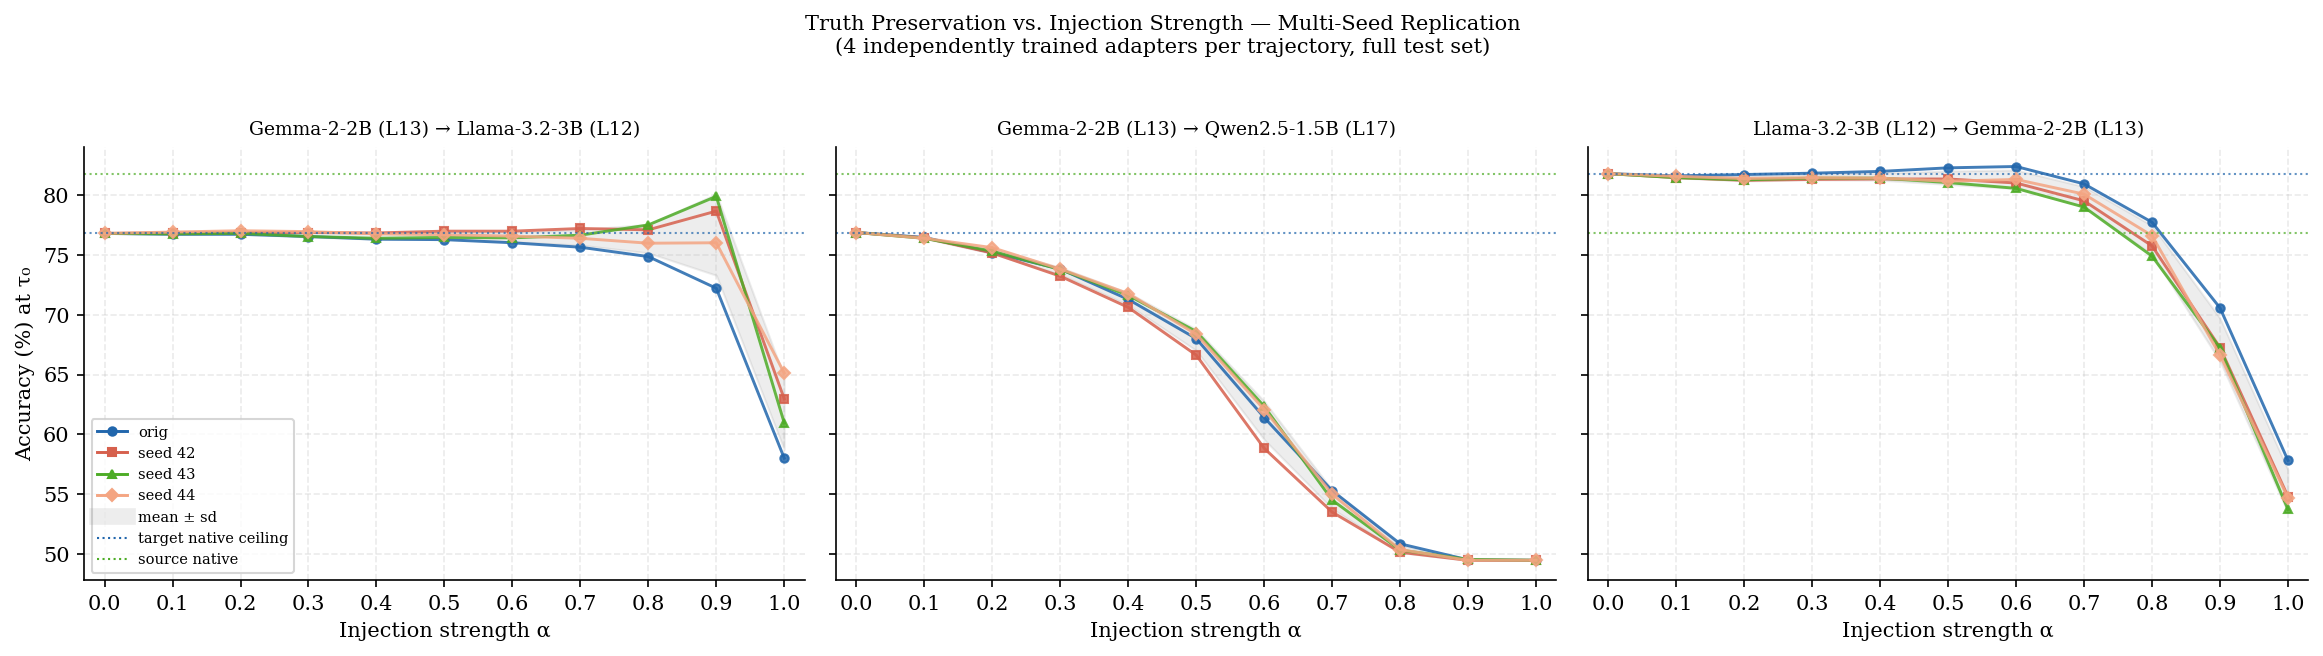

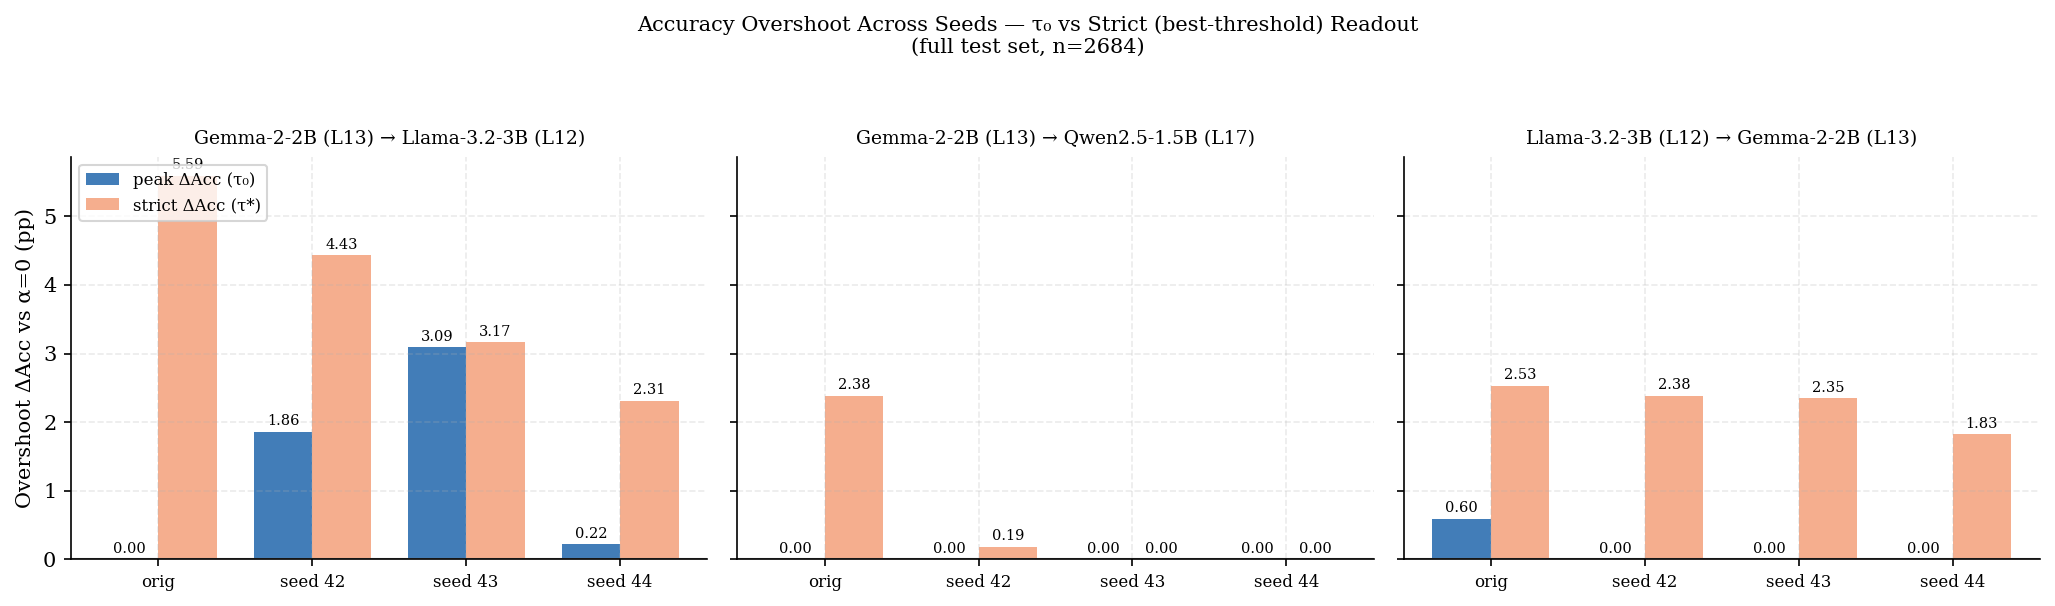

In [7]:
plots.use_style()
BLUE, RED, GREEN, GREY, ORANGE = plots.BLUE, plots.RED, plots.GREEN, plots.GREY, plots.ORANGE
ADAPTER_STYLES = {
    "origadapter": dict(color=BLUE,   marker="o", label="orig"),
    "seed42":      dict(color=RED,    marker="s", label="seed 42"),
    "seed43":      dict(color=GREEN,  marker="^", label="seed 43"),
    "seed44":      dict(color=ORANGE, marker="D", label="seed 44"),
}

# ---- per-run values on both evals (R2 plots the full-test-set columns) ----
r2 = []
for label in TRAJ_LABELS:
    for v in residuals.TRAINED_VARIANTS:
        tag = naming.adapter_tag(v)
        full = trajectories[label][v]["alpha_sweep"]
        simp = simple[(label, tag)]["alpha_sweep"]
        r2.append({"trajectory": label, "adapter": tag,
                   "tau0_peak_pp": metrics.tau0_peak_delta(full),
                   "strict_pp": metrics.strict_overshoot(full)[0],
                   "simple_tau0_peak_pp": metrics.tau0_peak_delta(simp),
                   "simple_strict_pp": metrics.strict_overshoot(simp)[0]})
r2_df = pd.DataFrame(r2)
print(r2_df.rename(columns={"tau0_peak_pp": "full τ0", "strict_pp": "full strict",
                            "simple_tau0_peak_pp": "simple τ0", "simple_strict_pp": "simple strict"})
      .round(2).to_string(index=False))
r2_df.to_csv(TABLE_DIR / "figR2_multiseed_overshoot.csv", index=False)

for r in r2:
    if r["adapter"] == "origadapter":
        e = te[(r["trajectory"], "trained (orig)")]
        assert abs(e["strict_dAcc_taustar_pp"] - r["strict_pp"]) < 1e-12, r
        assert abs(e["peak_dAcc_tau0_pp"] - r["tau0_peak_pp"]) < 1e-12, r
n_pos_simple = int((r2_df["simple_strict_pp"] > 0).sum())
n_pos_full = int((r2_df["strict_pp"] > 0).sum())
for name, col, n in (("simple statements (n=1599)", "simple_strict_pp", n_pos_simple),
                     ("full test set (n=2684)", "strict_pp", n_pos_full)):
    zeros = r2_df[r2_df[col] <= 0]
    print(f"\n{name}: strict overshoot > 0 on {n}/{len(r2_df)} runs "
          f"(range {r2_df[col].min():+.2f} to {r2_df[col].max():+.2f} pp)")
    for _, z in zeros.iterrows():
        print(f"   0.00 → {z['trajectory']} / {z['adapter']}")
if n_pos_simple != 12:
    raise SystemExit(f"rebuttal claim of record fails: simple-statement strict overshoot > 0 "
                     f"on {n_pos_simple}/12, not 12/12")

# ---- Figure R1: per-trajectory multi-seed alpha sweeps ----
fig, axes = plt.subplots(1, len(TRAJ_LABELS), figsize=(5.2 * len(TRAJ_LABELS), 4.2), sharey=True)
for ax, label in zip(np.atleast_1d(axes), TRAJ_LABELS):
    runs = trajectories[label]
    acc_stack = []
    for v in residuals.TRAINED_VARIANTS:
        sweep = runs[v]["alpha_sweep"]
        alphas = [r["alpha"] for r in sweep]
        accs = [r["accuracy"] * 100 for r in sweep]
        acc_stack.append(accs)
        st = ADAPTER_STYLES[naming.adapter_tag(v)]
        ax.plot(alphas, accs, color=st["color"], marker=st["marker"], ms=4, lw=1.4,
                alpha=0.85, label=st["label"])
    A = np.array(acc_stack)
    ax.fill_between(alphas, A.mean(0) - A.std(0, ddof=1), A.mean(0) + A.std(0, ddof=1),
                    color=GREY, alpha=0.15, label="mean ± sd")
    ref = runs["stmt_origadapter"]
    ax.axhline(ref["ceiling"]["target"]["accuracy"] * 100, color=BLUE,  lw=1, ls=":", alpha=0.7)
    ax.axhline(ref["ceiling"]["source"]["accuracy"] * 100, color=GREEN, lw=1, ls=":", alpha=0.7)
    ax.set_xticks(alphas); ax.set_xlim(-0.03, 1.03)
    ax.set_xlabel("Injection strength α", fontsize=10)
    ax.set_title(label, fontsize=9)
axes[0].set_ylabel("Accuracy (%) at τ₀", fontsize=10)
handles = [Line2D([0], [0], **{k: v for k, v in st.items() if k != "label"}, lw=1.4, ms=4,
                  label=st["label"]) for st in ADAPTER_STYLES.values()]
handles += [Line2D([0], [0], color=GREY, lw=8, alpha=0.15, label="mean ± sd"),
            Line2D([0], [0], color=BLUE,  lw=1, ls=":", label="target native ceiling"),
            Line2D([0], [0], color=GREEN, lw=1, ls=":", label="source native")]
axes[0].legend(handles=handles, fontsize=7, loc="lower left")
fig.suptitle("Truth Preservation vs. Injection Strength — Multi-Seed Replication\n"
             "(4 independently trained adapters per trajectory, full test set)", fontsize=10, y=1.03)
fig.tight_layout()
plots.save_fig(fig, FIG_DIR, "figR1_multiseed_alpha_sweeps")
plt.show()

# ---- Figure R2: overshoot summary bars ----
fig, axes = plt.subplots(1, len(TRAJ_LABELS), figsize=(4.6 * len(TRAJ_LABELS), 3.8), sharey=True)
width = 0.38
for ax, label in zip(np.atleast_1d(axes), TRAJ_LABELS):
    sub = r2_df[r2_df["trajectory"] == label]
    x = np.arange(len(sub))
    b1 = ax.bar(x - width / 2, sub["tau0_peak_pp"], width, color=BLUE,   alpha=0.85, label="peak ΔAcc (τ₀)")
    b2 = ax.bar(x + width / 2, sub["strict_pp"],    width, color=ORANGE, alpha=0.9,  label="strict ΔAcc (τ*)")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.05,
                    f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=7)
    ax.axhline(0, color=GREY, lw=1)
    ax.set_xticks(x); ax.set_xticklabels([ADAPTER_STYLES[a]["label"] for a in sub["adapter"]], fontsize=8)
    ax.set_title(label, fontsize=9)
axes[0].set_ylabel("Overshoot ΔAcc vs α=0 (pp)", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Accuracy Overshoot Across Seeds — τ₀ vs Strict (best-threshold) Readout\n"
             "(full test set, n=2684)", fontsize=10, y=1.05)
fig.tight_layout()
plots.save_fig(fig, FIG_DIR, "figR2_multiseed_overshoot_bars")
plt.show()

## Part 3 — baseline controls (R3–R5)

The trained (orig) adapter against the two Mse8 baselines: a random-weight MLP with output norm
matched to the native target, and the orig adapter's outputs permuted across examples.
R5 plots Table E's columns directly from the rows checked in Part 1.

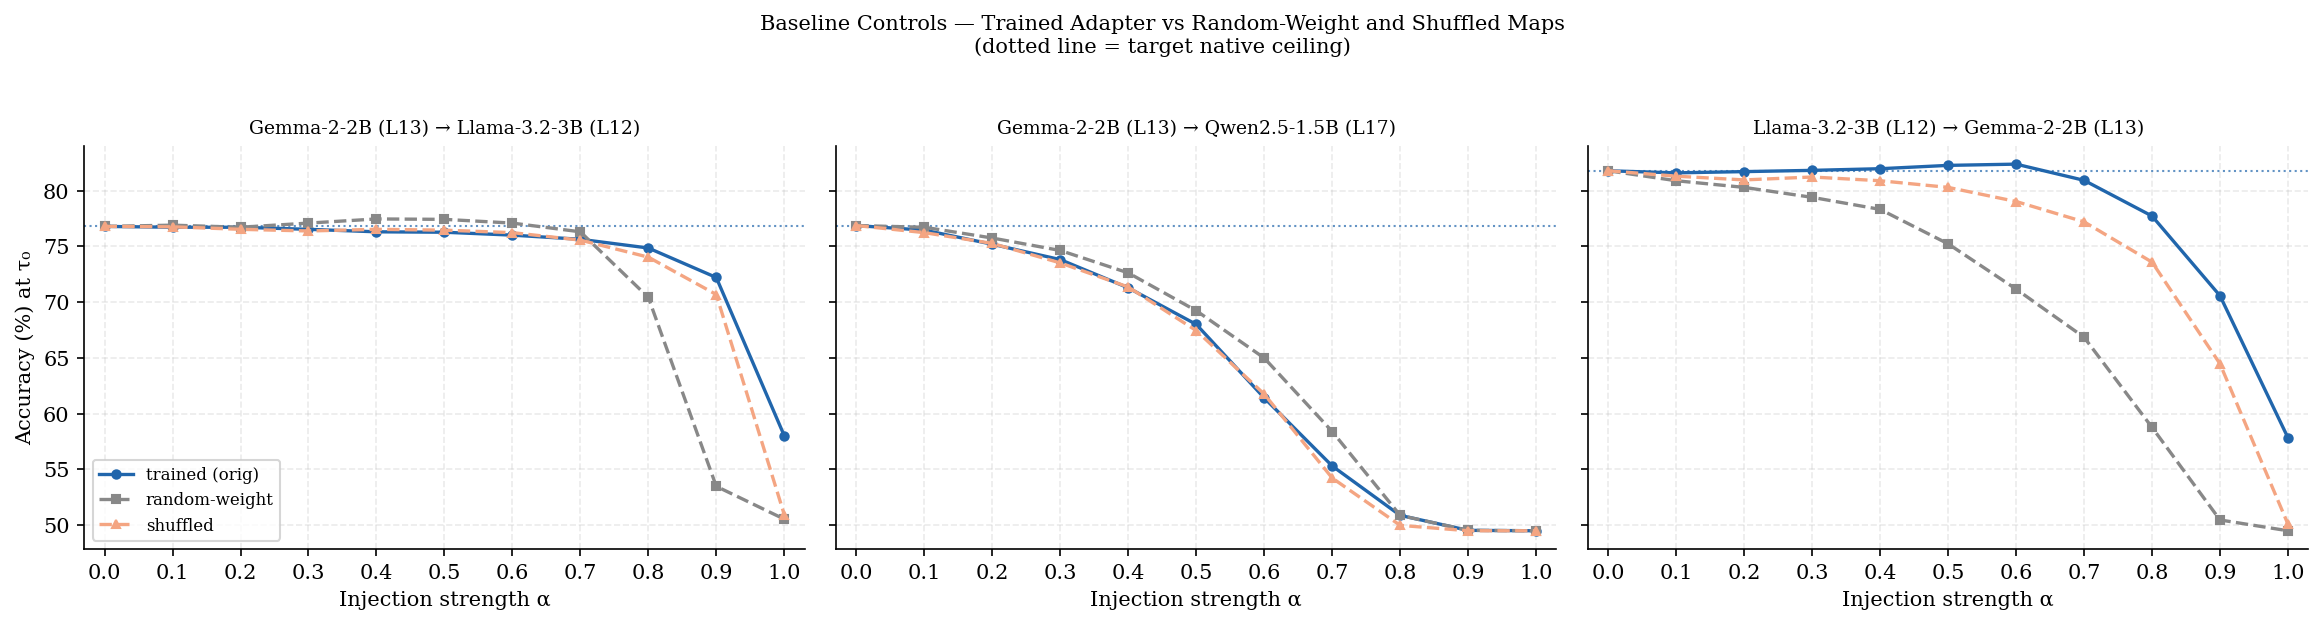

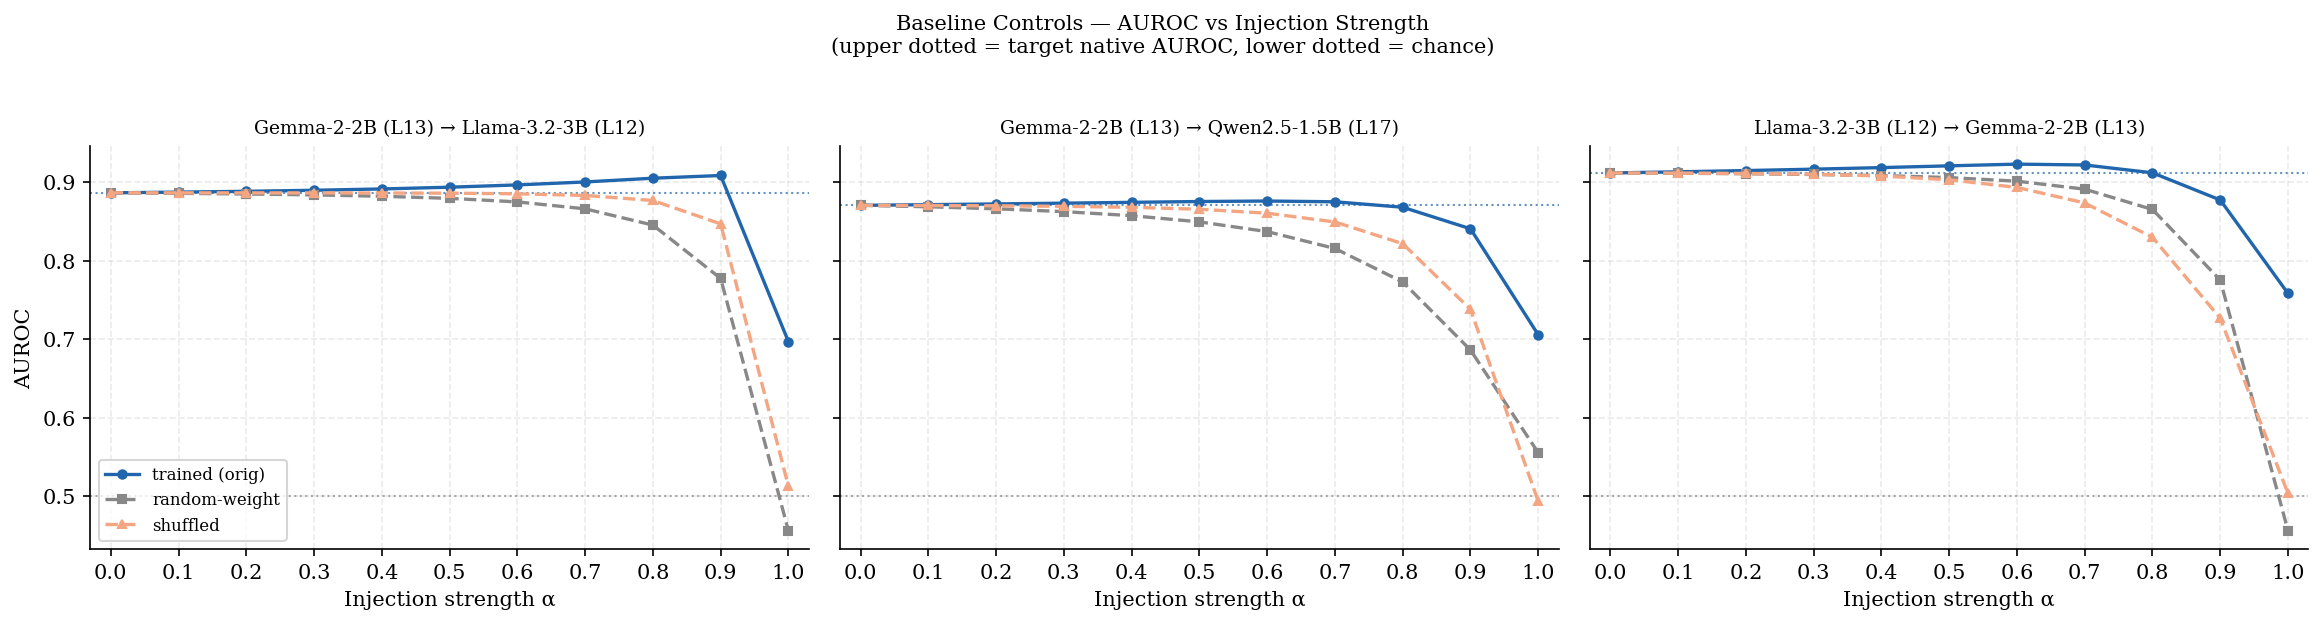

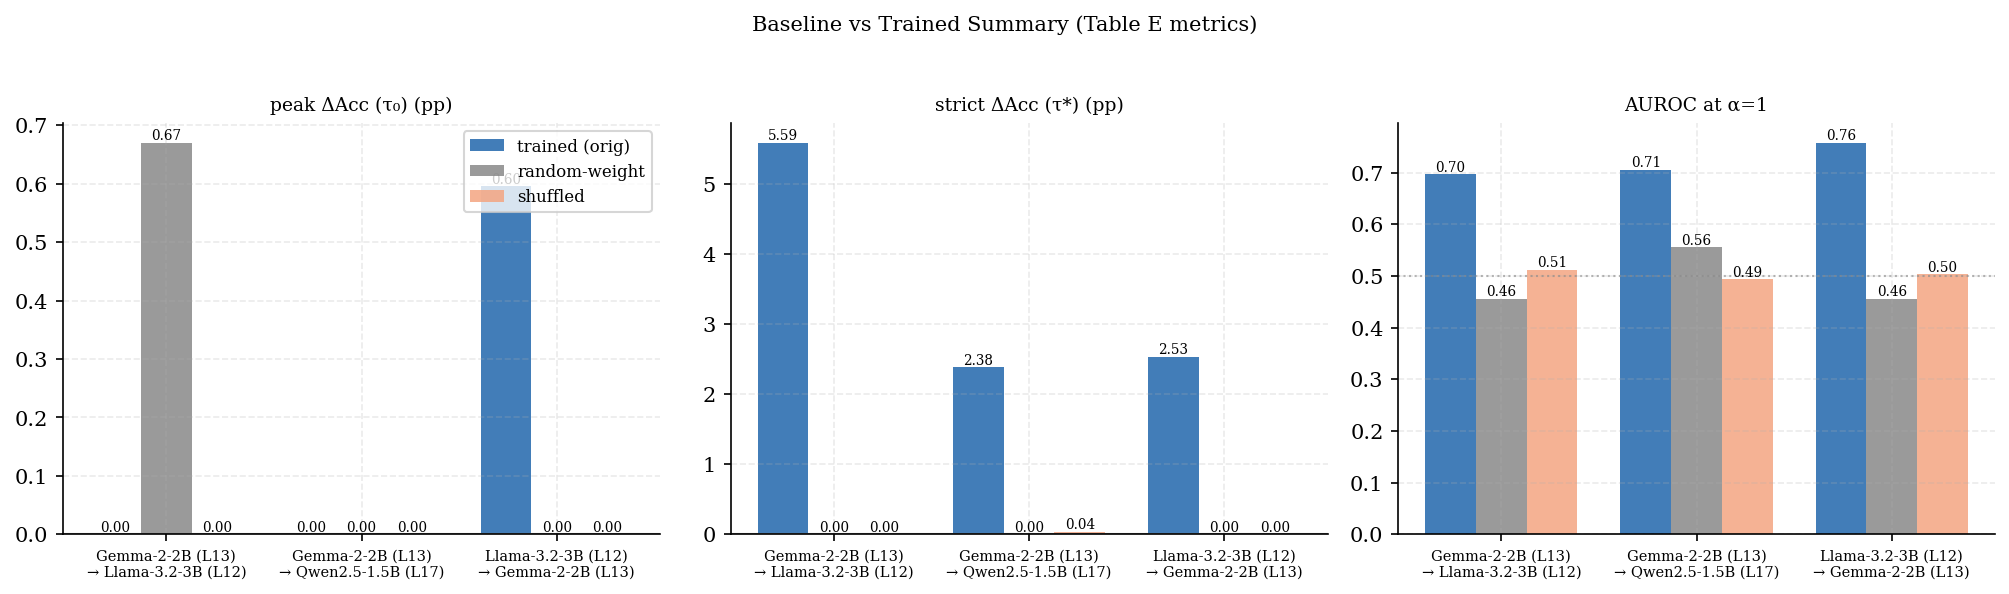

In [8]:
BASELINE_ORDER = [
    ("stmt_origadapter", "trained (orig)", BLUE,   "o", "-"),
    ("stmt_randbase",    "random-weight",  GREY,   "s", "--"),
    ("stmt_shufbase",    "shuffled",       ORANGE, "^", "--"),
]

def sweep_panels(metric, ylabel, title, stem, ref_lines):
    fig, axes = plt.subplots(1, len(TRAJ_LABELS), figsize=(5.2 * len(TRAJ_LABELS), 4.0), sharey=True)
    for ax, label in zip(np.atleast_1d(axes), TRAJ_LABELS):
        runs = trajectories[label]
        for y, color in ref_lines(runs["stmt_origadapter"]):
            ax.axhline(y, color=color, lw=1, ls=":", alpha=0.7)
        for v, name, color, marker, ls in BASELINE_ORDER:
            sweep = runs[v]["alpha_sweep"]
            alphas = [r["alpha"] for r in sweep]
            ax.plot(alphas, [metric(r) for r in sweep], color=color, marker=marker, ms=4,
                    lw=1.6, ls=ls, label=name)
        ax.set_xticks(alphas); ax.set_xlim(-0.03, 1.03)
        ax.set_xlabel("Injection strength α", fontsize=10)
        ax.set_title(label, fontsize=9)
    axes[0].set_ylabel(ylabel, fontsize=10)
    axes[0].legend(fontsize=8, loc="lower left")
    fig.suptitle(title, fontsize=10, y=1.03)
    fig.tight_layout()
    plots.save_fig(fig, FIG_DIR, stem)
    plt.show()

# ---- Figure R3: accuracy vs alpha ----
sweep_panels(lambda r: r["accuracy"] * 100, "Accuracy (%) at τ₀",
             "Baseline Controls — Trained Adapter vs Random-Weight and Shuffled Maps\n"
             "(dotted line = target native ceiling)",
             "figR3_baseline_accuracy_sweeps",
             lambda ref: [(ref["ceiling"]["target"]["accuracy"] * 100, BLUE)])

# ---- Figure R4: AUROC vs alpha ----
sweep_panels(lambda r: r["auroc"], "AUROC",
             "Baseline Controls — AUROC vs Injection Strength\n"
             "(upper dotted = target native AUROC, lower dotted = chance)",
             "figR4_baseline_auroc_sweeps",
             lambda ref: [(ref["ceiling"]["target"]["auroc"], BLUE), (0.5, GREY)])

# ---- Figure R5: Table E as grouped bars ----
MAP_NAME = {v: name for v, name, *_ in BASELINE_ORDER}
panels = [("peak ΔAcc (τ₀) (pp)", "peak_dAcc_tau0_pp"),
          ("strict ΔAcc (τ*) (pp)", "strict_dAcc_taustar_pp"),
          ("AUROC at α=1",          "auroc_a1")]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
width = 0.26
for ax, (title, col) in zip(axes, panels):
    x = np.arange(len(TRAJ_LABELS))
    for j, (v, name, color, *_r) in enumerate(BASELINE_ORDER):
        vals = [te[(label, name)][col] for label in TRAJ_LABELS]
        bars = ax.bar(x + (j - 1) * width, vals, width, color=color, alpha=0.85, label=name)
        for b, val in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{val:.2f}",
                    ha="center", va="bottom", fontsize=6.5)
    ax.axhline(0.5 if "AUROC" in title else 0, color=GREY, lw=1,
               ls=":" if "AUROC" in title else "-", alpha=0.6 if "AUROC" in title else 1)
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace(" → ", "\n→ ") for l in TRAJ_LABELS], fontsize=7)
    ax.set_title(title, fontsize=9)
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Baseline vs Trained Summary (Table E metrics)", fontsize=10, y=1.03)
fig.tight_layout()
plots.save_fig(fig, FIG_DIR, "figR5_baseline_summary_bars")
plt.show()

## Part 4 — residual geometry (R6–R8)

Plotted from the unrounded Table F rows checked in Part 1, so the figures and the table cannot
drift apart.

**Reading R8.** A dead t_G read with a live re-probe means the truth information is still present
in the map's outputs but rotated off the target's t_G direction. Note that the **random-weight**
baseline re-probes *higher* than the trained adapters: a random MLP preserves linear separability.
Re-probe recoverability therefore shows the information survives the map. It is not specific to
learned maps; strict overshoot (R5, middle panel) is what separates trained from random.

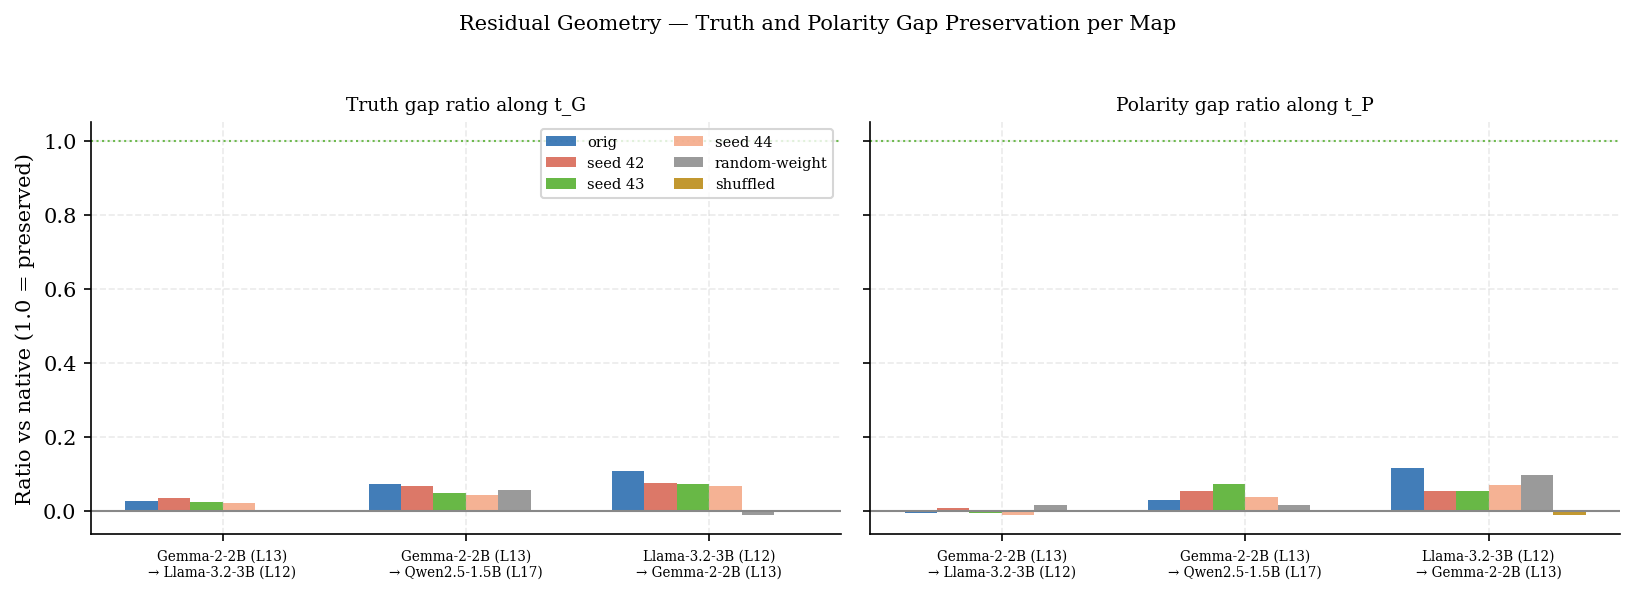

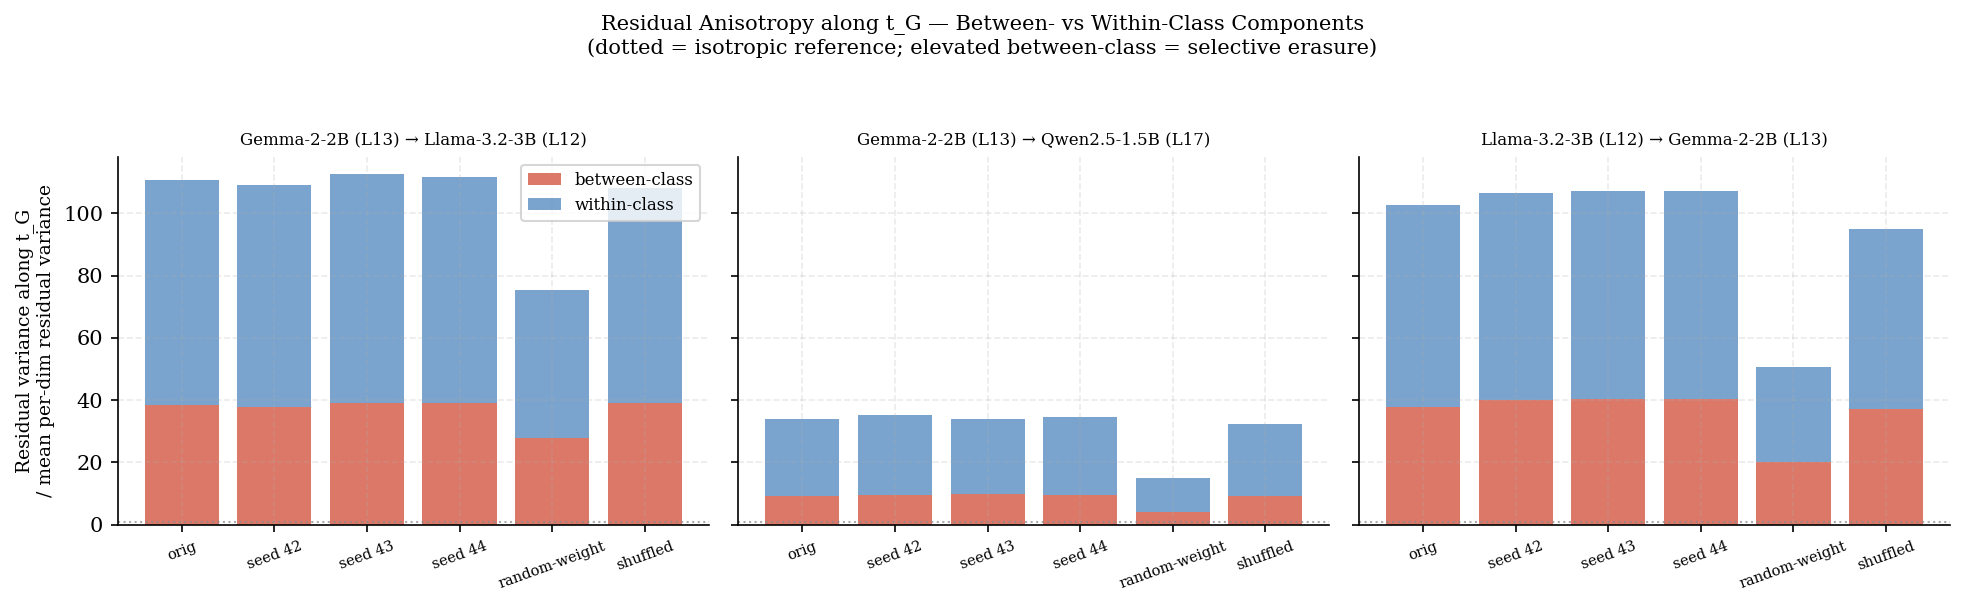

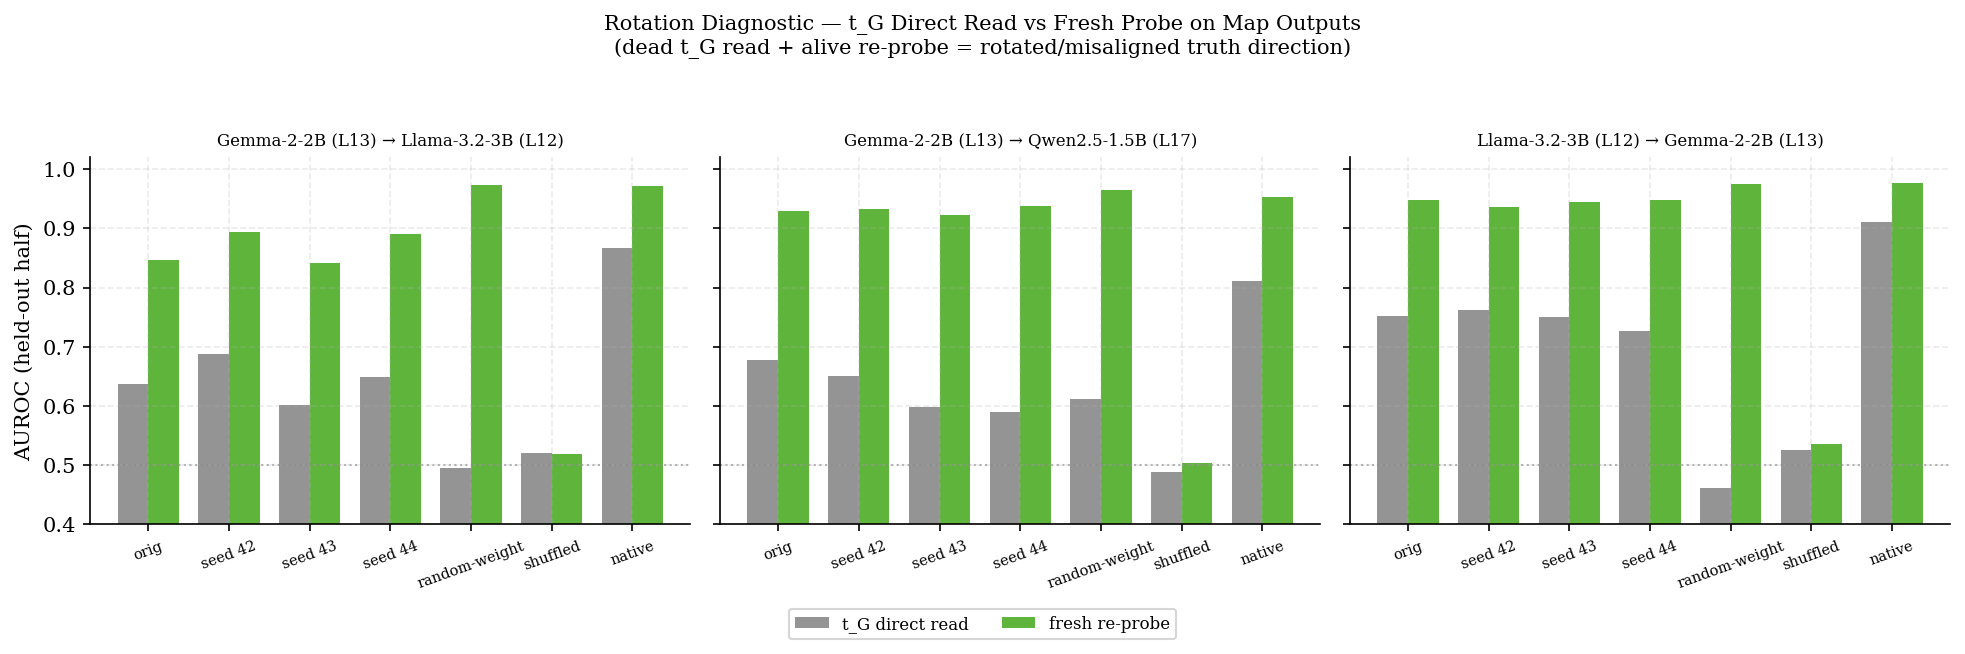

In [9]:
MAPS = ["orig", "seed42", "seed43", "seed44", "rand_out", "shuf_out"]
MAP_LABELS = {"orig": "orig", "seed42": "seed 42", "seed43": "seed 43", "seed44": "seed 44",
              "rand_out": "random-weight", "shuf_out": "shuffled", residuals.NATIVE_LABEL: "native"}
MAP_COLORS = {"orig": BLUE, "seed42": RED, "seed43": GREEN, "seed44": ORANGE,
              "rand_out": GREY, "shuf_out": "#B8860B"}
TRAJ_STEMS = sorted(tf["trajectory"].unique())
def cell(t, m, col):
    s = tf[(tf["trajectory"] == t) & (tf["map"] == m)][col]
    return float(s.iloc[0]) if len(s) else np.nan
# dump stem -> the display label R1-R5 use
STEM_LABEL = {residuals.trajectory_slug(b): naming.display_pair_label(*naming.parse_adapter_repo(b))
              for b in residuals.TRAJECTORY_ADAPTERS}
def stem_label(t, sep=" → "):
    return STEM_LABEL[t].replace(" → ", sep)

# ---- Figure R6: gap ratios along t_G and t_P ----
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
width = 0.8 / len(MAPS)
for ax, (col, name) in zip(axes, [("gap_ratio_tG", "Truth gap ratio along t_G"),
                                  ("polgap_ratio_tP", "Polarity gap ratio along t_P")]):
    x = np.arange(len(TRAJ_STEMS))
    for j, m in enumerate(MAPS):
        ax.bar(x + (j - (len(MAPS) - 1) / 2) * width, [cell(t, m, col) for t in TRAJ_STEMS],
               width, color=MAP_COLORS[m], alpha=0.85, label=MAP_LABELS[m])
    ax.axhline(1.0, color=GREEN, lw=1, ls=":", alpha=0.8)
    ax.axhline(0.0, color=GREY, lw=1)
    ax.set_xticks(x); ax.set_xticklabels([stem_label(t, "\n→ ") for t in TRAJ_STEMS], fontsize=6.5)
    ax.set_title(name, fontsize=9)
axes[0].set_ylabel("Ratio vs native (1.0 = preserved)", fontsize=10)
axes[0].legend(fontsize=7, loc="upper right", ncol=2)
fig.suptitle("Residual Geometry — Truth and Polarity Gap Preservation per Map", fontsize=10, y=1.03)
fig.tight_layout()
plots.save_fig(fig, FIG_DIR, "figR6_gap_ratios")
plt.show()

# ---- Figure R7: residual anisotropy, between vs within class ----
fig, axes = plt.subplots(1, len(TRAJ_STEMS), figsize=(4.4 * len(TRAJ_STEMS), 3.8), sharey=True)
for ax, t in zip(np.atleast_1d(axes), TRAJ_STEMS):
    x = np.arange(len(MAPS))
    between = [cell(t, m, "aniso_between") for m in MAPS]
    within  = [cell(t, m, "aniso_within") for m in MAPS]
    ax.bar(x, between, color=RED,  alpha=0.85, label="between-class")
    ax.bar(x, within, bottom=between, color=BLUE, alpha=0.6, label="within-class")
    ax.axhline(1.0, color=GREY, lw=1, ls=":", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels([MAP_LABELS[m] for m in MAPS], fontsize=7, rotation=20)
    ax.set_title(stem_label(t, " → "), fontsize=8)
axes[0].set_ylabel("Residual variance along t_G\n/ mean per-dim residual variance", fontsize=9)
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Residual Anisotropy along t_G — Between- vs Within-Class Components\n"
             "(dotted = isotropic reference; elevated between-class = selective erasure)",
             fontsize=10, y=1.05)
fig.tight_layout()
plots.save_fig(fig, FIG_DIR, "figR7_residual_anisotropy")
plt.show()

# ---- Figure R8: t_G direct read vs re-probe AUROC ----
fig, axes = plt.subplots(1, len(TRAJ_STEMS), figsize=(4.4 * len(TRAJ_STEMS), 3.8), sharey=True)
width = 0.38
keys = MAPS + [residuals.NATIVE_LABEL]
for ax, t in zip(np.atleast_1d(axes), TRAJ_STEMS):
    x = np.arange(len(keys))
    ax.bar(x - width / 2, [cell(t, m, "auroc_tG_read") for m in keys], width,
           color=GREY, alpha=0.9, label="t_G direct read")
    ax.bar(x + width / 2, [cell(t, m, "auroc_reprobe") for m in keys], width,
           color=GREEN, alpha=0.9, label="fresh re-probe")
    ax.axhline(0.5, color=GREY, lw=1, ls=":", alpha=0.6)
    ax.set_ylim(0.4, 1.02)
    ax.set_xticks(x); ax.set_xticklabels([MAP_LABELS[m] for m in keys], fontsize=7, rotation=20)
    ax.set_title(stem_label(t, " → "), fontsize=8)
axes[0].set_ylabel("AUROC (held-out half)", fontsize=10)
h, l = axes[0].get_legend_handles_labels()   # below the panels, clear of the bars
fig.legend(h, l, fontsize=8, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Rotation Diagnostic — t_G Direct Read vs Fresh Probe on Map Outputs\n"
             "(dead t_G read + alive re-probe = rotated/misaligned truth direction)",
             fontsize=10, y=1.05)
fig.tight_layout()
plots.save_fig(fig, FIG_DIR, "figR8_reprobe_diagnostic")
plt.show()

Table A: ✓ reproduces the published CSV
Table B: ✓ reproduces the published CSV
Table C: ✓ reproduces the published CSV
Table D: ✓ reproduces the published CSV
Table long: ✓ reproduces the published CSV

Per trajectory x statement type (means over the 4 adapters):

                           trajectory       group    n  native  native_sd  plateau_min  a1_mean  a1_min  a1_max   drop  turn_down
Gemma-2-2B (L13) → Llama-3.2-3B (L12)      simple 1080   0.923        0.0        0.925    0.698   0.630   0.747  0.225        1.0
Gemma-2-2B (L13) → Llama-3.2-3B (L12)     negated  519   0.969        0.0        0.969    0.779   0.704   0.820  0.190        1.0
Gemma-2-2B (L13) → Llama-3.2-3B (L12) conjunction  607   0.961        0.0        0.961    0.829   0.784   0.879  0.131        1.0
Gemma-2-2B (L13) → Llama-3.2-3B (L12) disjunction  478   0.699        0.0        0.688    0.557   0.502   0.628  0.142        0.9
Gemma-2-2B (L13) → Llama-3.2-3B (L12)         all 2684   0.887        0.0        0.8

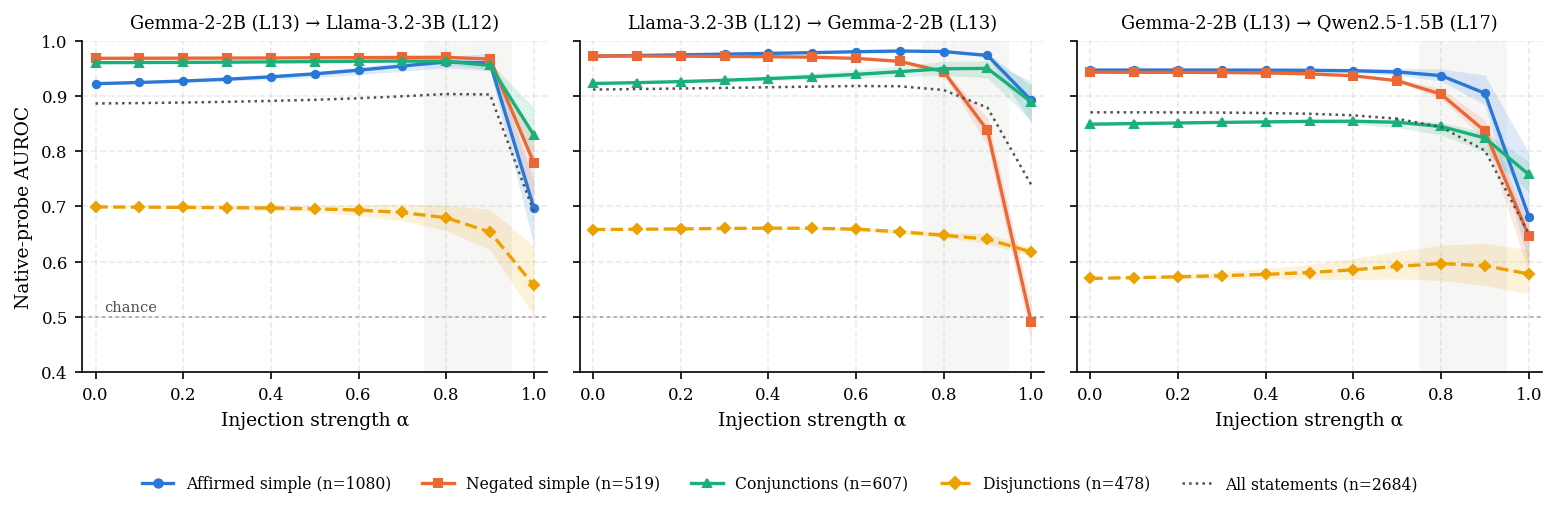

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PLATEAU_ALPHAS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
PLATEAU_TOL = 0.02          # same tolerance as Table C
TURN_DOWN = 0.02            # "turns down": group-mean AUROC more than this below native
GROUPS = ["simple", "negated", "conjunction", "disjunction"]
GROUP_NAMES = {"simple": "Affirmed simple", "negated": "Negated simple",
               "conjunction": "Conjunctions", "disjunction": "Disjunctions", "all": "All statements"}
# paper order: high, moderate, floor
TRAJ_ORDER = ["Gemma-2-2B (L13) → Llama-3.2-3B (L12)",
              "Llama-3.2-3B (L12) → Gemma-2-2B (L13)",
              "Gemma-2-2B (L13) → Qwen2.5-1.5B (L17)"]
TRAJ_TEX = {TRAJ_ORDER[0]: r"Gemma 2 2B $\to$ Llama 3.2 3B",
            TRAJ_ORDER[1]: r"Llama 3.2 3B $\to$ Gemma 2 2B",
            TRAJ_ORDER[2]: r"Gemma 2 2B $\to$ Qwen 2.5 1.5B"}

# ---- 1. recompute and check against the published tables ----------------------------------
st_tables = residuals.statement_type_tables(SWEEPS)
st_problems = residuals.compare_statement_tables(st_tables, SWEEPS / "analysis_statement_types")
for key, probs in st_problems.items():
    print(f"Table {key}: " + ("✓ reproduces the published CSV" if not probs
                             else f"✗ {len(probs)} difference(s)"))
    for p in probs:
        print("   ", p)
if any(st_problems.values()):
    raise SystemExit("REGRESSION — a published statement-type number would change")

long_df = st_tables["long"]
ci_df = st_tables["D"]
assert set(long_df["trajectory"]) == set(TRAJ_ORDER), sorted(set(long_df["trajectory"]))

# ---- 2. per run, then per trajectory x group ------------------------------------------------
run_rows = []
for (traj, group, adapter), s in long_df.groupby(["trajectory", "group", "adapter"]):
    a = s.set_index("alpha")["auroc"]
    run_rows.append({"trajectory": traj, "group": group, "adapter": adapter, "n": int(s["n"].iloc[0]),
                     "native": a[0.0], "plateau_min": a[PLATEAU_ALPHAS].min(), "a1": a[1.0]})
runs = pd.DataFrame(run_rows)
runs["plateau_holds"] = runs["plateau_min"] >= runs["native"] - PLATEAU_TOL

summary_rows = []
for traj in TRAJ_ORDER:
    for group in GROUPS + ["all"]:
        r = runs[(runs.trajectory == traj) & (runs.group == group)]
        m = long_df[(long_df.trajectory == traj) & (long_df.group == group)].groupby("alpha")["auroc"].mean()
        below = [a for a in m.index if m[a] < m[0.0] - TURN_DOWN]
        summary_rows.append({
            "trajectory": traj, "group": group, "n": int(r["n"].iloc[0]),
            "native": r["native"].mean(), "native_sd": r["native"].std(),
            "plateau_min": r["plateau_min"].mean(),
            "a1_mean": r["a1"].mean(), "a1_min": r["a1"].min(), "a1_max": r["a1"].max(),
            "drop": r["native"].mean() - r["a1"].mean(),
            "turn_down": below[0] if below else np.nan,
        })
summ = pd.DataFrame(summary_rows)
pd.set_option("display.width", 200)
print("\nPer trajectory x statement type (means over the 4 adapters):\n")
print(summ.round(3).to_string(index=False))
summ.to_csv(TABLE_DIR / "table_statement_types_summary.csv", index=False)

# ---- 3. the claims the appendix makes ------------------------------------------------------
def S(traj, group, col):
    return float(summ[(summ.trajectory == traj) & (summ.group == group)][col].iloc[0])

GL, LG, GQ = TRAJ_ORDER
typed = runs[runs.group.isin(GROUPS)]
fails = typed[~typed.plateau_holds]
ci_neg = ci_df[(ci_df.trajectory == LG) & (ci_df.group == "negated") & (ci_df.alpha == 1.0)]

claims = {
    "native AUROC is identical across the four adapters (fixed probe, alpha=0)":
        (summ["native_sd"].max() < 1e-9, f"max sd {summ['native_sd'].max():.2g}"),
    "group sizes are 1080 / 519 / 607 / 478 and sum to 2684":
        ([S(GL, g, "n") for g in GROUPS] == [1080, 519, 607, 478], ""),
    "disjunctions are weakly separable natively (AUROC < 0.70 on all three)":
        (all(S(t, "disjunction", "native") < 0.70 for t in TRAJ_ORDER),
         ", ".join(f"{S(t, 'disjunction', 'native'):.3f}" for t in TRAJ_ORDER)),
    "other types are well separated natively (AUROC >= 0.84)":
        (all(S(t, g, "native") >= 0.84 for t in TRAJ_ORDER for g in GROUPS[:3]), ""),
    "plateau holds in 47 of the 48 run x type cells":
        (len(fails) == 1, "; ".join(f"{r.trajectory[:12]} {r.group} {r.adapter} "
                                    f"({r.plateau_min - r.native:+.3f})" for r in fails.itertuples())),
    "conjunctions lose the least among the well-separated types, on all three":
        (all(S(t, "conjunction", "drop") < min(S(t, "simple", "drop"), S(t, "negated", "drop"))
             for t in TRAJ_ORDER),
         ", ".join(f"{S(t, 'conjunction', 'drop'):.3f}" for t in TRAJ_ORDER)),
    "negated lose the most on Llama->Gemma and Gemma->Qwen":
        (all(S(t, "negated", "drop") > max(S(t, g, "drop") for g in ("simple", "conjunction", "disjunction"))
             for t in (LG, GQ)),
         f"{S(LG, 'negated', 'drop'):.3f}, {S(GQ, 'negated', 'drop'):.3f}"),
    "on Gemma->Llama, affirmed simple lose more than negated":
        (S(GL, "simple", "drop") > S(GL, "negated", "drop"),
         f"{S(GL, 'simple', 'drop'):.3f} vs {S(GL, 'negated', 'drop'):.3f}"),
    "Llama->Gemma negated at alpha=1: every adapter's 95% CI contains 0.5":
        (len(ci_neg) == 4 and bool(((ci_neg.ci_lo <= 0.5) & (ci_neg.ci_hi >= 0.5)).all()),
         "; ".join(f"{r.adapter} {r.auroc:.3f} [{r.ci_lo:.3f}, {r.ci_hi:.3f}]" for r in ci_neg.itertuples())),
    "negated turn down first (alpha=0.8) on Llama->Gemma and Gemma->Qwen":
        (all(S(t, "negated", "turn_down") == 0.8 for t in (LG, GQ)) and
         all(S(t, g, "turn_down") > 0.8 for t in (LG, GQ) for g in ("simple", "conjunction")),
         ", ".join(f"{t[:12]}: " + " ".join(f"{g[:4]}={S(t, g, 'turn_down')}" for g in GROUPS)
                   for t in TRAJ_ORDER)),
}
print("\n--- claims ---")
for claim, (ok, detail) in claims.items():
    print(f"{'✓' if ok else '✗'} {claim}" + (f"   [{detail}]" if detail else ""))
if not all(ok for ok, _ in claims.values()):
    raise SystemExit("a statement-type claim in the appendix no longer holds")

counts = runs[runs.group.isin(GROUPS)].assign(at_chance=lambda d: d.a1 <= 0.60) \
    .groupby("group")["at_chance"].sum().reindex(GROUPS)
print("\nruns with alpha=1 AUROC <= 0.60 (Table C's collapse criterion), of 12: "
      + ", ".join(f"{g} {int(c)}" for g, c in counts.items()))

# ---- 4. LaTeX table body for tab:statement-types --------------------------------------------
tex = []
for traj in TRAJ_ORDER:
    for i, group in enumerate(GROUPS + ["all"]):
        r = summ[(summ.trajectory == traj) & (summ.group == group)].iloc[0]
        first = TRAJ_TEX[traj] if i == 0 else ""
        name = GROUP_NAMES[group]
        tex.append(f"{first:<32} & {name:<16} & {int(r['n']):>4} & ${r['native']:.2f}$ & "
                   f"${r['plateau_min']:.2f}$ & ${r['a1_mean']:.2f}$ & "
                   f"$[{r['a1_min']:.2f}, {r['a1_max']:.2f}]$ & ${-r['drop']:+.2f}$ \\\\")
    tex.append(r"\midrule")
tex = tex[:-1]
(TABLE_DIR / "table_statement_types_rows.tex").write_text("\n".join(tex) + "\n")
print("\nLaTeX rows -> " + str(TABLE_DIR / "table_statement_types_rows.tex"))
print("\n".join(tex))

# ---- 5. Figure R9 ----------------------------------------------------------------------------
# Categorical slots 1-4 of the dataviz reference palette (passes the CVD checks; markers and
# line styles carry identity too). "All statements" is a neutral reference line.
STYLE = {
    "simple":      dict(color="#2a78d6", marker="o", ls="-"),
    "negated":     dict(color="#eb6834", marker="s", ls="-"),
    "conjunction": dict(color="#1baf7a", marker="^", ls="-"),
    "disjunction": dict(color="#eda100", marker="D", ls="--"),
    "all":         dict(color="#52514e", marker=None, ls=":"),
}
plots.use_style()
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3), sharey=True)
for ax, traj in zip(axes, TRAJ_ORDER):
    ax.axvspan(0.75, 0.95, color="#a9a8a3", alpha=0.10, lw=0)
    ax.axhline(0.5, color="#a9a8a3", lw=0.8, ls=(0, (2, 2)))
    for group in GROUPS + ["all"]:
        piv = long_df[(long_df.trajectory == traj) & (long_df.group == group)] \
            .pivot(index="alpha", columns="adapter", values="auroc").sort_index()
        a = piv.index.values
        st = STYLE[group]
        if group != "all":
            ax.fill_between(a, piv.min(axis=1), piv.max(axis=1), color=st["color"], alpha=0.15, lw=0)
        ax.plot(a, piv.mean(axis=1), color=st["color"], ls=st["ls"], marker=st["marker"], ms=3.5,
                lw=1.6 if group != "all" else 1.2, zorder=3)
    ax.set_title(traj, fontsize=8.5)
    ax.set_xticks(np.round(np.arange(0, 1.01, 0.2), 1))
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel("Injection strength α", fontsize=9)
    ax.tick_params(labelsize=8)
axes[0].set_ylabel("Native-probe AUROC", fontsize=9)
axes[0].text(0.02, 0.505, "chance", fontsize=7, color="#52514e", va="bottom")
handles = [Line2D([], [], color=STYLE[g]["color"], ls=STYLE[g]["ls"], marker=STYLE[g]["marker"],
                  ms=4, lw=1.6, label=f"{GROUP_NAMES[g]} (n={S(GL, g, 'n'):.0f})") for g in GROUPS]
handles.append(Line2D([], [], color=STYLE["all"]["color"], ls=":", lw=1.2, label="All statements (n=2684)"))
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=7.5, frameon=False,
           bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.07, 1, 1))
plots.save_fig(fig, FIG_DIR, "figR9_statement_types_auroc")
plt.show()

In [11]:
TRAINED = ["orig", "seed42", "seed43", "seed44"]
STRONG = ["gemma2-2b-instruct_l13_to_llama3_2-3b-instruct_l12",
          "llama3_2-3b-instruct_l12_to_gemma2-2b-instruct_l13"]
FLOOR = "gemma2-2b-instruct_l13_to_qwen2_5-1_5b-instruct_l17"


def rows(traj, maps):
    return tf[(tf.trajectory == traj) & (tf["map"].isin(maps))]


tr_all = tf[tf["map"].isin(TRAINED)]
nat = tf[tf["map"] == residuals.NATIVE_LABEL]
rnd, shf = tf[tf["map"] == "rand_out"], tf[tf["map"] == "shuf_out"]

claims_res = {
    "native re-probe is 0.95-0.98":
        (nat.auroc_reprobe.min() >= 0.95 - REPROBE_TOL and nat.auroc_reprobe.max() <= 0.98 + REPROBE_TOL,
         f"{nat.auroc_reprobe.min():.4f}-{nat.auroc_reprobe.max():.4f}"),
    "re-probe beats the t_G read by >= 0.17 on every trained map":
        ((tr_all.auroc_reprobe - tr_all.auroc_tG_read).min() >= 0.17 - REPROBE_TOL,
         f"min margin {(tr_all.auroc_reprobe - tr_all.auroc_tG_read).min():.4f}"),
    "trained t_G read is 0.59-0.76":
        ((round(tr_all.auroc_tG_read.min(), 2), round(tr_all.auroc_tG_read.max(), 2)) == (0.59, 0.76),
         f"{tr_all.auroc_tG_read.min():.4f}-{tr_all.auroc_tG_read.max():.4f}"),
    "trained polarity gap ratio along t_P is -0.01 to 0.12":
        ((round(tr_all.polgap_ratio_tP.min(), 2), round(tr_all.polgap_ratio_tP.max(), 2)) == (-0.01, 0.12),
         f"{tr_all.polgap_ratio_tP.min():.4f}-{tr_all.polgap_ratio_tP.max():.4f}"),
    "random map re-probes above every trained adapter (0.97-0.98)":
        (rnd.auroc_reprobe.min() > tr_all.auroc_reprobe.max(),
         f"random {rnd.auroc_reprobe.min():.4f}-{rnd.auroc_reprobe.max():.4f}, "
         f"trained max {tr_all.auroc_reprobe.max():.4f}"),
    "shuffled control re-probes at 0.50-0.54":
        (shf.auroc_reprobe.min() >= 0.50 - REPROBE_TOL and shf.auroc_reprobe.max() <= 0.54 + REPROBE_TOL,
         f"{shf.auroc_reprobe.min():.4f}-{shf.auroc_reprobe.max():.4f}"),
    "stronger trajectories: every trained map beats the random map on gap ratio and t_G read":
        (all((rows(t, TRAINED).gap_ratio_tG.min() > rows(t, ["rand_out"]).gap_ratio_tG.iloc[0]) and
             (rows(t, TRAINED).auroc_tG_read.min() > rows(t, ["rand_out"]).auroc_tG_read.iloc[0])
             for t in STRONG), ""),
    "floor trajectory: the random map falls inside the trained range on both":
        (rows(FLOOR, TRAINED).gap_ratio_tG.min() <= rows(FLOOR, ["rand_out"]).gap_ratio_tG.iloc[0]
         <= rows(FLOOR, TRAINED).gap_ratio_tG.max() and
         rows(FLOOR, TRAINED).auroc_tG_read.min() <= rows(FLOOR, ["rand_out"]).auroc_tG_read.iloc[0]
         <= rows(FLOOR, TRAINED).auroc_tG_read.max(),
         f"random {rows(FLOOR, ['rand_out']).gap_ratio_tG.iloc[0]:.3f} / "
         f"{rows(FLOOR, ['rand_out']).auroc_tG_read.iloc[0]:.3f}"),
    "anisotropy does not separate trained from shuffled (within 11% of the trained mean)":
        (all(abs(rows(t, ["shuf_out"]).resid_aniso_tG.iloc[0] / rows(t, TRAINED).resid_aniso_tG.mean() - 1) < 0.11
             for t in tf.trajectory.unique()),
         ", ".join(f"{rows(t, ['shuf_out']).resid_aniso_tG.iloc[0]:.1f} vs "
                   f"{rows(t, TRAINED).resid_aniso_tG.mean():.1f}" for t in sorted(tf.trajectory.unique()))),
}
for claim, (ok, detail) in claims_res.items():
    print(f"{'✓' if ok else '✗'} {claim}" + (f"   [{detail}]" if detail else ""))
if not all(ok for ok, _ in claims_res.values()):
    raise SystemExit("a residual-geometry appendix claim no longer holds")

✓ native re-probe is 0.95-0.98   [0.9539-0.9762]
✓ re-probe beats the t_G read by >= 0.17 on every trained map   [min margin 0.1737]
✓ trained t_G read is 0.59-0.76   [0.5895-0.7626]
✓ trained polarity gap ratio along t_P is -0.01 to 0.12   [-0.0103-0.1168]
✓ random map re-probes above every trained adapter (0.97-0.98)   [random 0.9650-0.9750, trained max 0.9487]
✓ shuffled control re-probes at 0.50-0.54   [0.5037-0.5351]
✓ stronger trajectories: every trained map beats the random map on gap ratio and t_G read
✓ floor trajectory: the random map falls inside the trained range on both   [random 0.058 / 0.611]
✓ anisotropy does not separate trained from shuffled (within 11% of the trained mean)   [108.1 vs 111.0, 32.3 vs 34.4, 94.8 vs 105.9]


In [ ]:
# --- manifest ---------------------------------------------------------------
manifest = {
    "run_ids": RUN_IDS, "dumps": [p.name for p in DUMPS],
    "reprobe_tol": REPROBE_TOL,
    "tables_reproduce_published": not any(problems.values()),
    "strict_overshoot_positive": {"simple_statements": f"{n_pos_simple}/12",
                                  "full_test_set": f"{n_pos_full}/12"},
    "simple_run_ids": SIMPLE_IDS,
    "figures": sorted(p.name for p in FIG_DIR.glob("*.pdf")),
    "provenance": storage.provenance(),
}
json.dump(manifest, open(FIG_DIR / "manifest.json", "w"), indent=2)
print(f"{len(manifest['figures'])} figures (pdf + png) → {FIG_DIR}\ntables → {TABLE_DIR}")

8 figures (pdf + png) → /content/figures_rebuttal
tables → /content/rebuttal_tables
